In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [16]:
df = pd.read_csv(r"D:\computational_biology_projects\enzyme_kinetics\enzyme_data.csv") # this dataset has two rows

In [17]:
df


,substrate,velocity
0,0.5,12
1,1.0,20
2,2.0,33
3,4.0,50
4,8.0,67
5,16.0,80


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   substrate  6 non-null      float64
 1   velocity   6 non-null      int64  
dtypes: float64(1), int64(1)
memory usage: 228.0 bytes


In [19]:
df.describe()

,substrate,velocity
count,6.000000,6.000000
mean,5.250000,43.666667
std,5.930852,26.763159
min,0.500000,12.000000
25%,1.250000,23.250000
50%,3.000000,41.500000
75%,7.000000,62.750000
max,16.000000,80.000000


<function matplotlib.pyplot.show(close=None, block=None)>

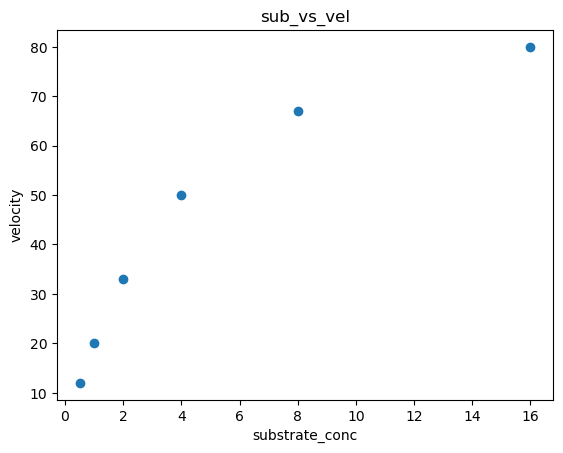

In [20]:
plt.scatter(df['substrate'],df['velocity'])
plt.xlabel('substrate_conc')
plt.ylabel('velocity')
plt.title('sub_vs_vel')
plt.show

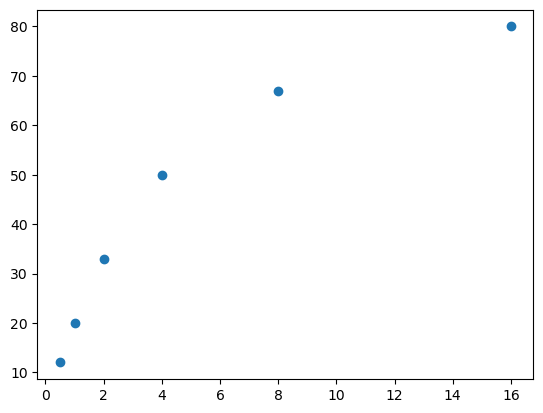

In [23]:
plt_1 = plt.scatter(df['substrate'],df['velocity'])
plt_1

In [24]:
from scipy.optimize import curve_fit

In [32]:
# Velocity v = (S* Vmax/ S+Km) this micheal metens equation 

def micheal_menten (S, Vmax, km ): # def model ( X , params1 , params2 ) X is the input independent variable , so in this case S substrate 
    return(Vmax * S)/(S + km)

In [33]:
# the return is the v value , from dataset no.2 entry substrste 2 velocity 33, the Vmax = 100 , Km = 4 
micheal_menten(2 , 100 , 4)

33.333333333333336

In [36]:
params, covarience = curve_fit( micheal_menten, df["substrate"], df["velocity"])
# curve_fit gives two outout- parameters(multiple) and covarience- used to identify confidence levels


In [37]:
Vmax = params[0]
km = params[1]
print (Vmax , km) # this output value  from the curvr_fit would be the best fit for  our data set

100.01750163699916 3.98584706920481


In [38]:
# creating range of numbers to create smooth fit , will predict their velocities with obtained vmax and km and plot a graph to see if the prediction fits the data set
s_range = np.linspace(0, 20, 100)
s_range[:10]

array([0.        , 0.2020202 , 0.4040404 , 0.60606061, 0.80808081,
       1.01010101, 1.21212121, 1.41414141, 1.61616162, 1.81818182])

In [40]:
predicted_velocity = micheal_menten(s_range , Vmax, km)

In [41]:
predicted_velocity[:10]

array([ 0.        ,  4.82478421,  9.2055006 , 13.20075924, 16.85929067,
       20.22194343, 23.32321568, 26.19244312, 28.85472982, 31.33168468])

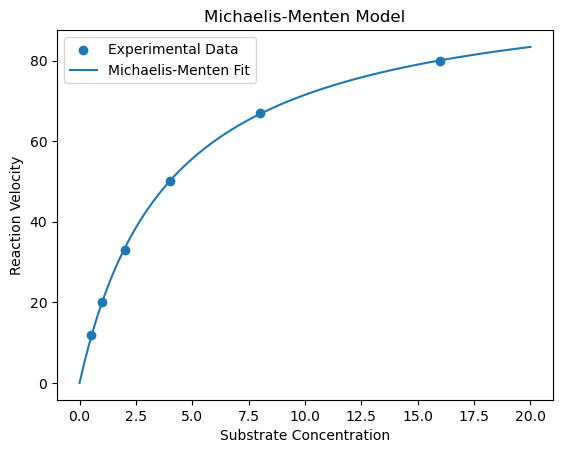

In [46]:
plt.scatter(
    df["substrate"],
    df["velocity"],
    label="Experimental Data"
)

plt.plot(
    s_range,
    predicted_velocity,
    label="Michaelis-Menten Fit"
)

plt.xlabel("Substrate Concentration")
plt.ylabel("Reaction Velocity")
plt.title("Michaelis-Menten Model")

plt.legend()
plt.savefig("michaelis_menten_fit.png")
plt.show()

In [47]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'enzyme_kinetcs.ipynb', 'michaelis_menten_fit.png']


In [48]:
print(os.path.abspath("michaelis_menten_fit.png"))

C:\Users\narma\comp_bio_projects\michaelis_menten_fit.png


In [49]:
print(os.getcwd())

C:\Users\narma\comp_bio_projects
